# GCR circuit examples

This notebook builds small, inspectable circuits first and ends with a larger N2 resource comparison. Each section is meant to run from top to bottom without helper functions.


In [38]:
import ffsim
import ffsim.qiskit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyscf.lib
from ffsim.qiskit.gates import PrepareHartreeFockJW
from ffsim.qiskit.gates.ucj import UCJOpSpinBalancedJW
from qiskit import QuantumCircuit
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import UnrollCustomDefinitions
from xquces import utils as xq_utils
from xquces.gcr import IGCR2SpinBalancedParameterization, IGCR2SpinRestrictedParameterization, IGCR3SpinRestrictedParameterization, IGCR4SpinRestrictedParameterization
from xquces.qiskit import CircuitStatsJob, circuit_stats, pretty_print_circuit_stats
from xquces.qiskit.gates import igcr2_stateprep_jw_circuit, igcr3_stateprep_jw_circuit, igcr4_stateprep_jw_circuit
from xquces.ucj import UCJBalancedDFSeed, UCJRestrictedProjectedDFSeed
pyscf.lib.num_threads(4)

4

In [39]:
# Keep the visual circuits at the Givens/phase-operation level.
decomposed_basis = ["xx_plus_yy", "rzz", "cp", "p", "x", "rz", "cx", "mcphase"]
unroll_to_decomposed_basis = PassManager([UnrollCustomDefinitions(SessionEquivalenceLibrary, basis_gates=decomposed_basis)]* 6)
metrics = ["parameters", "depth", "gates", "two_qubit_gates"]
metric_labels = ["Parameters", "Depth", "Gates", "Two-qubit gates"]

## 1. H2: ffsim UCJ and xquces iGCR-2

We start with H2 in a minimal basis. Both circuits use the spin-balanced UCJ/iGCR-2 construction used in the original circuit example.


In [40]:
h2_R = 0.74
h2_basis = "sto-6g"

h2_mol = xq_utils.build_diatom("H", "H", h2_R, h2_basis)
h2_mf = xq_utils.run_rhf(h2_mol)
h2_ccsd = xq_utils.run_rccsd(h2_mf)

h2_norb = h2_mol.nao_nr()
h2_nelec = xq_utils.active_nelec_from_mo_occ(h2_mf, range(h2_norb))
h2_nocc = h2_nelec[0]

h2_ucj = ffsim.UCJOpSpinBalanced.from_t_amplitudes(np.asarray(h2_ccsd.t2, dtype=np.float64), t1=np.asarray(h2_ccsd.t1, dtype=np.complex128), n_reps=1)
h2_ffsim_circuit = QuantumCircuit(2 * h2_norb)
h2_ffsim_circuit.append(PrepareHartreeFockJW(h2_norb, h2_nelec), h2_ffsim_circuit.qubits)
h2_ffsim_circuit.append(UCJOpSpinBalancedJW(h2_ucj), h2_ffsim_circuit.qubits)

h2_ucj_balanced = UCJBalancedDFSeed(t2=h2_ccsd.t2, t1=h2_ccsd.t1, n_reps=1).build_ansatz()
h2_igcr2 = IGCR2SpinBalancedParameterization(norb=h2_norb, nocc=h2_nocc)
h2_igcr2_ansatz = h2_igcr2.ansatz_from_parameters(h2_igcr2.parameters_from_ucj_ansatz(h2_ucj_balanced))
h2_igcr2_circuit = igcr2_stateprep_jw_circuit(h2_igcr2_ansatz)

h2_ffsim_decomposed = unroll_to_decomposed_basis.run(ffsim.qiskit.PRE_INIT.run(h2_ffsim_circuit))
h2_igcr2_decomposed = unroll_to_decomposed_basis.run(h2_igcr2_circuit)


       ansatz  parameters  depth  gates  two_qubit_gates
    ffsim UCJ          14      8     20               10
xquces iGCR-2          10      5     12                6


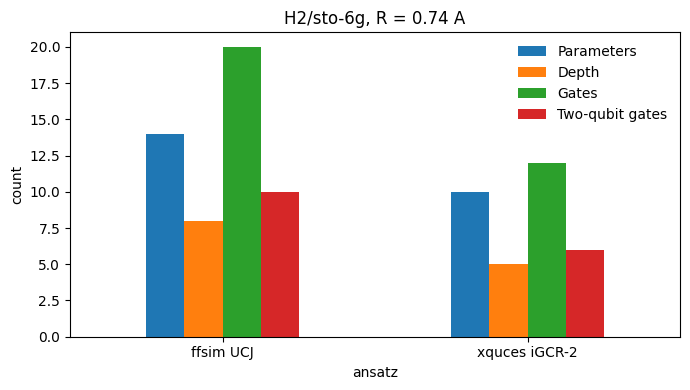

In [41]:
h2_parameters = {
    "ffsim UCJ": h2_ucj.n_params(
        norb=h2_norb, n_reps=1, with_final_orbital_rotation=True
    ),
    "xquces iGCR-2": h2_igcr2.n_params,
}
h2_stats_raw = [
    circuit_stats(h2_ffsim_decomposed, "ffsim UCJ"),
    circuit_stats(h2_igcr2_decomposed, "xquces iGCR-2"),
]
h2_stats = pd.DataFrame(
    [
        {
            "ansatz": item.label,
            "parameters": h2_parameters[item.label],
            "depth": item.depth,
            "gates": item.gate_count,
            "two_qubit_gates": item.two_qubit_gate_count,
        }
        for item in h2_stats_raw
    ]
)

print(h2_stats.to_string(index=False))

ax = h2_stats.set_index("ansatz")[metrics].plot.bar(figsize=(7, 4), rot=0)
ax.set_ylabel("count")
ax.set_xticklabels(ax.get_xticklabels(), ha="center")
ax.set_title(f"H2/{h2_basis}, R = {h2_R} A")
ax.legend(metric_labels, frameon=False)
plt.tight_layout()


### ffsim UCJ circuit

`PRE_INIT` exposes the ffsim UCJ state-preparation circuit in the same decomposed basis used for the statistics.


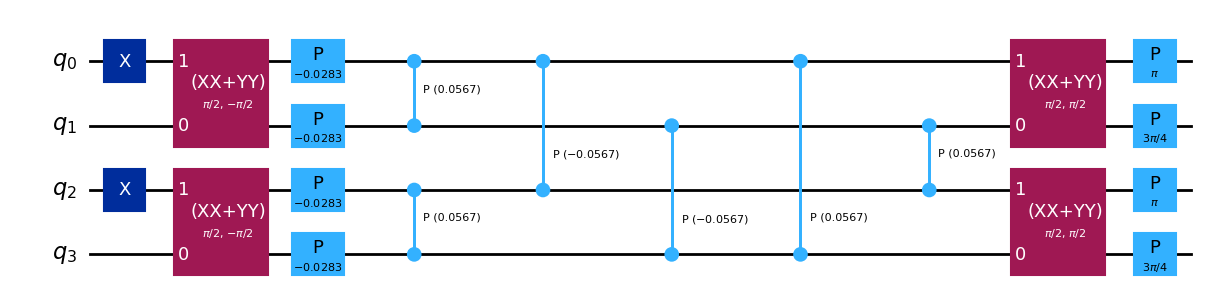

In [42]:
h2_ffsim_decomposed.draw("mpl", fold=-1, idle_wires=False)


### xquces iGCR-2 circuit


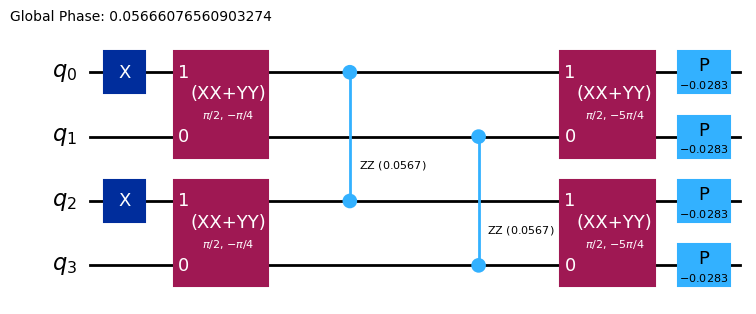

In [43]:
h2_igcr2_decomposed.draw("mpl", fold=-1, idle_wires=False)


## 2. H4 square: spin-restricted iGCR-2, iGCR-3 and iGCR-4

In [44]:
h4_R = 1.20
h4_basis = "sto-6g"

h4_mol = xq_utils.build_h4_rectangle(h4_R, h4_R, h4_basis)
h4_mf = xq_utils.run_rhf(h4_mol)
h4_ccsd = xq_utils.run_rccsd(h4_mf)

h4_norb = h4_mol.nao_nr()
h4_nelec = xq_utils.active_nelec_from_mo_occ(h4_mf, range(h4_norb))
h4_nocc = h4_nelec[0]
h4_ucj_restricted = UCJRestrictedProjectedDFSeed(t2=h4_ccsd.t2, t1=h4_ccsd.t1, n_reps=1).build_ansatz()

h4_igcr2 = IGCR2SpinRestrictedParameterization(norb=h4_norb, nocc=h4_nocc, real_right_orbital_chart=True)
h4_igcr3 = IGCR3SpinRestrictedParameterization(norb=h4_norb, nocc=h4_nocc, real_right_orbital_chart=True)
h4_igcr4 = IGCR4SpinRestrictedParameterization(norb=h4_norb, nocc=h4_nocc, real_right_orbital_chart=True)

h4_igcr2_ansatz = h4_igcr2.ansatz_from_parameters(h4_igcr2.parameters_from_ucj_ansatz(h4_ucj_restricted))
h4_igcr3_ansatz = h4_igcr3.ansatz_from_parameters(
    h4_igcr3.parameters_from_ucj_ansatz(
        h4_ucj_restricted, tau_scale=1e-10, omega_scale=1e-10
    )
)
h4_igcr4_ansatz = h4_igcr4.ansatz_from_parameters(
    h4_igcr4.parameters_from_ucj_ansatz(
        h4_ucj_restricted,
        tau_scale=1e-10,
        omega_scale=1e-10,
        eta_scale=1e-10,
        rho_scale=1e-10,
        sigma_scale=1e-10,
    )
)

h4_igcr2_decomposed = unroll_to_decomposed_basis.run(igcr2_stateprep_jw_circuit(h4_igcr2_ansatz))
h4_igcr3_decomposed = unroll_to_decomposed_basis.run(
    igcr3_stateprep_jw_circuit(h4_igcr3_ansatz)
)
h4_igcr4_decomposed = unroll_to_decomposed_basis.run(
    igcr4_stateprep_jw_circuit(h4_igcr4_ansatz)
)


ansatz  parameters  depth  gates  two_qubit_gates
iGCR-2          22     16     64               44
iGCR-3          28    313    404              300
iGCR-4          31    797    894              720


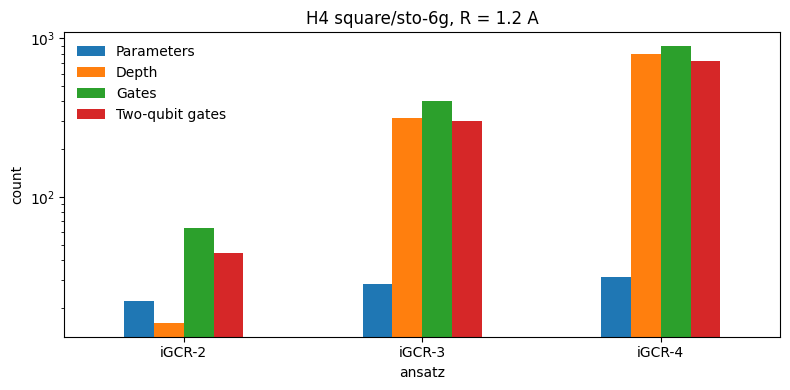

In [45]:
h4_parameters = {
    "iGCR-2": h4_igcr2.n_params,
    "iGCR-3": h4_igcr3.n_params,
    "iGCR-4": h4_igcr4.n_params,
}
h4_stats_raw = [
    circuit_stats(h4_igcr2_decomposed, "iGCR-2"),
    circuit_stats(h4_igcr3_decomposed, "iGCR-3"),
    circuit_stats(h4_igcr4_decomposed, "iGCR-4"),
]
h4_stats = pd.DataFrame(
    [
        {
            "ansatz": item.label,
            "parameters": h4_parameters[item.label],
            "depth": item.depth,
            "gates": item.gate_count,
            "two_qubit_gates": item.two_qubit_gate_count,
        }
        for item in h4_stats_raw
    ]
)

print(h4_stats.to_string(index=False))

ax = h4_stats.set_index("ansatz")[metrics].plot.bar(figsize=(8, 4), rot=0)
ax.set_yscale("log")
ax.set_ylabel("count")
ax.set_title(f"H4 square/{h4_basis}, R = {h4_R} A")
ax.legend(metric_labels, frameon=False)
plt.tight_layout()


# ***iGCR-2 circuit for $H_4$/STO-3G***


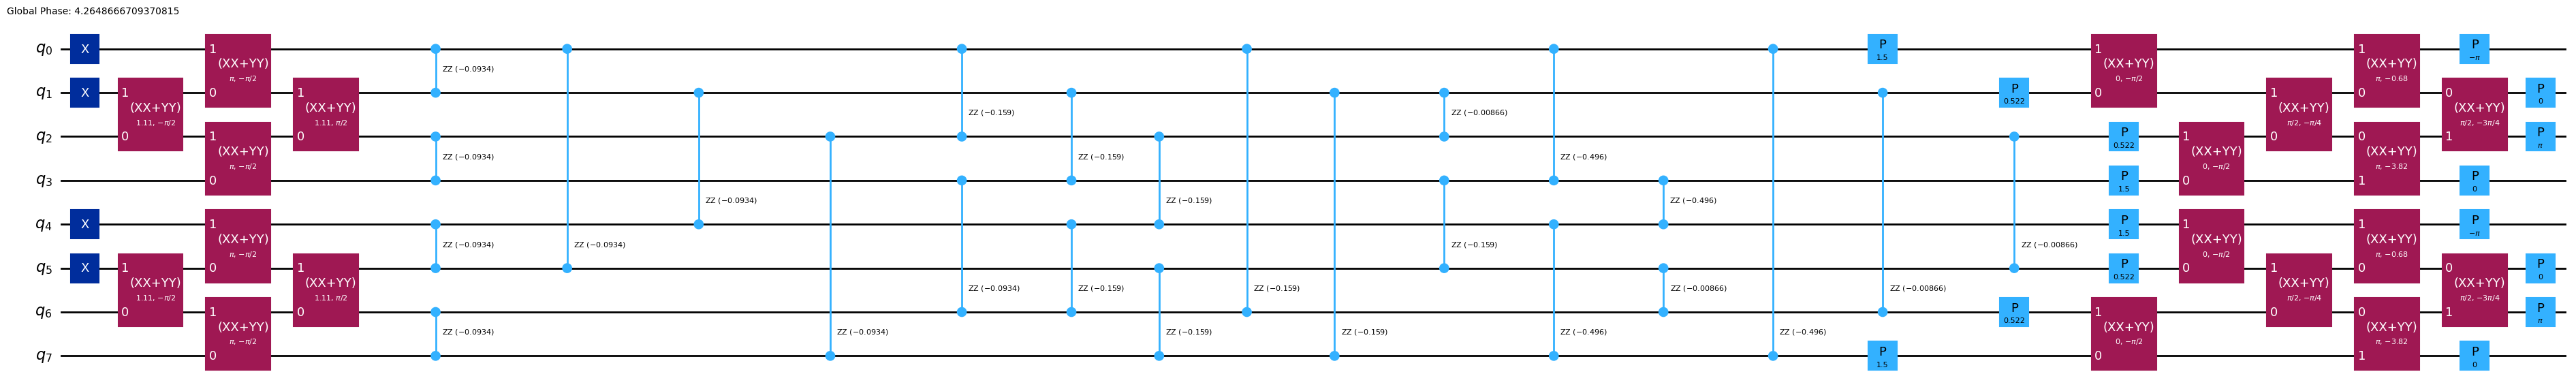

In [46]:
h4_igcr2_decomposed.draw("mpl", fold=80, idle_wires=False)


# ***iGCR-3 circuit for $H_4$/STO-3G***


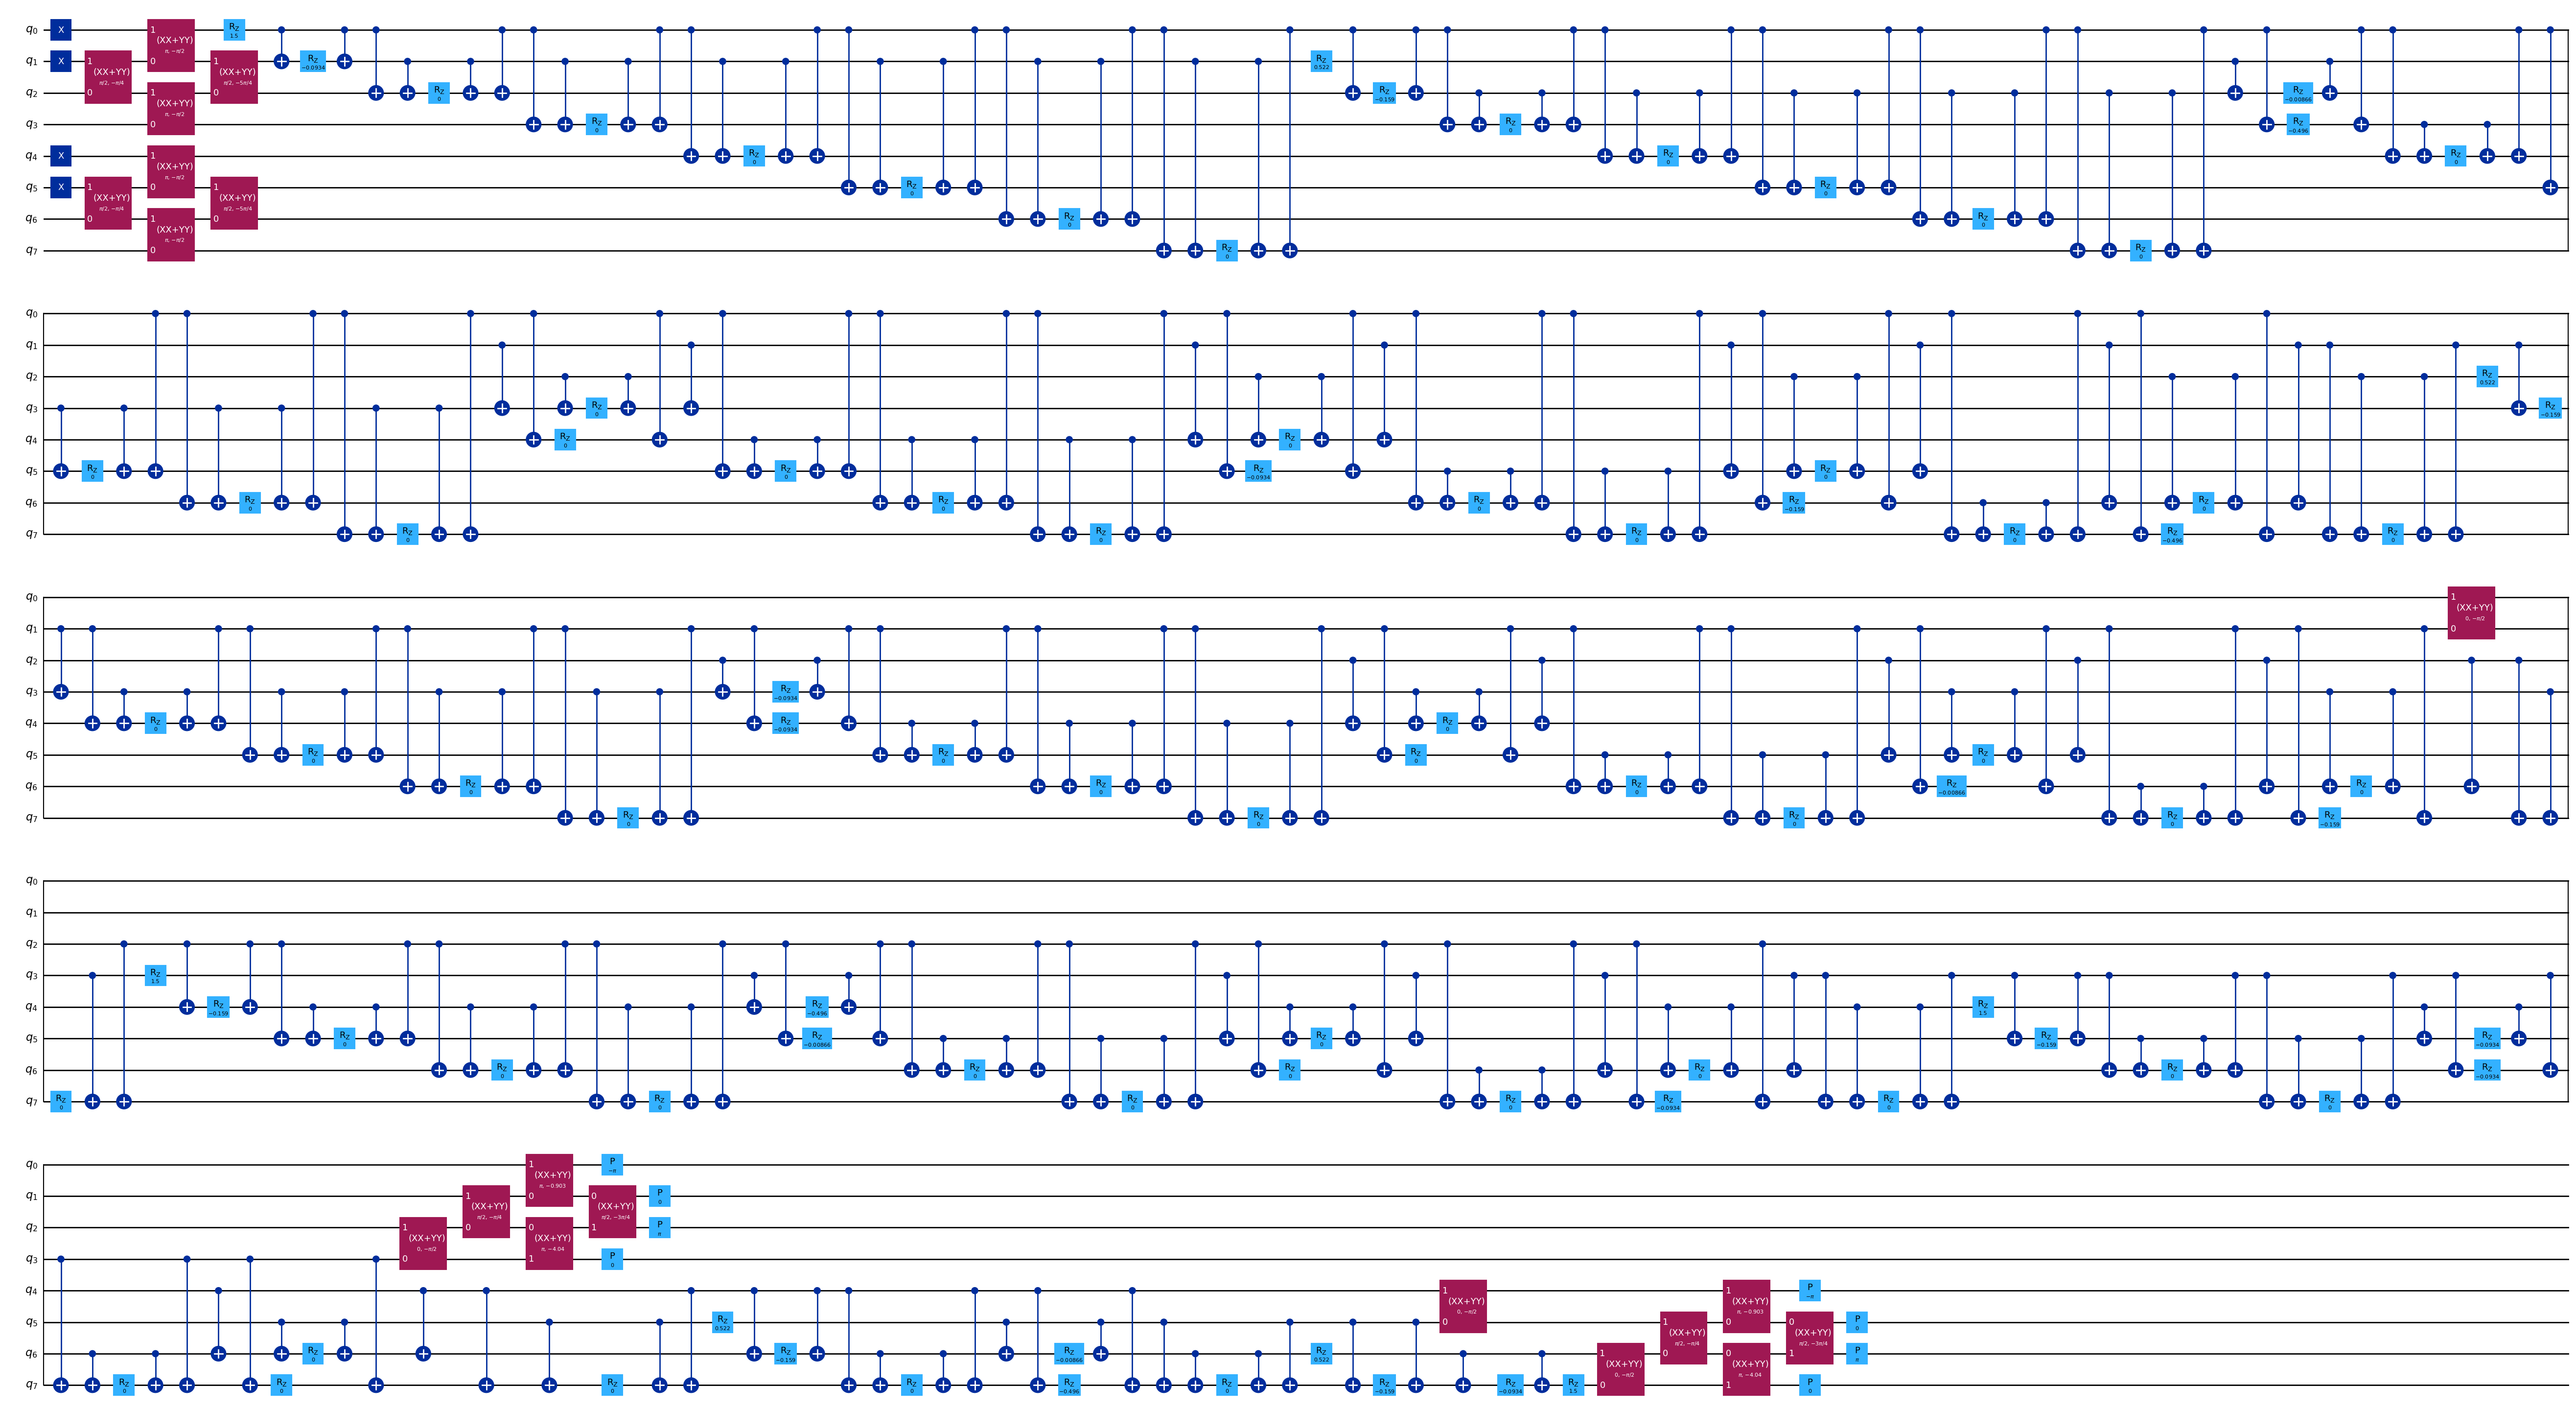

In [47]:
h4_igcr3_decomposed.draw("mpl", fold=80, idle_wires=False)


# ***iGCR-4 circuit for $H_4$/STO-3G***


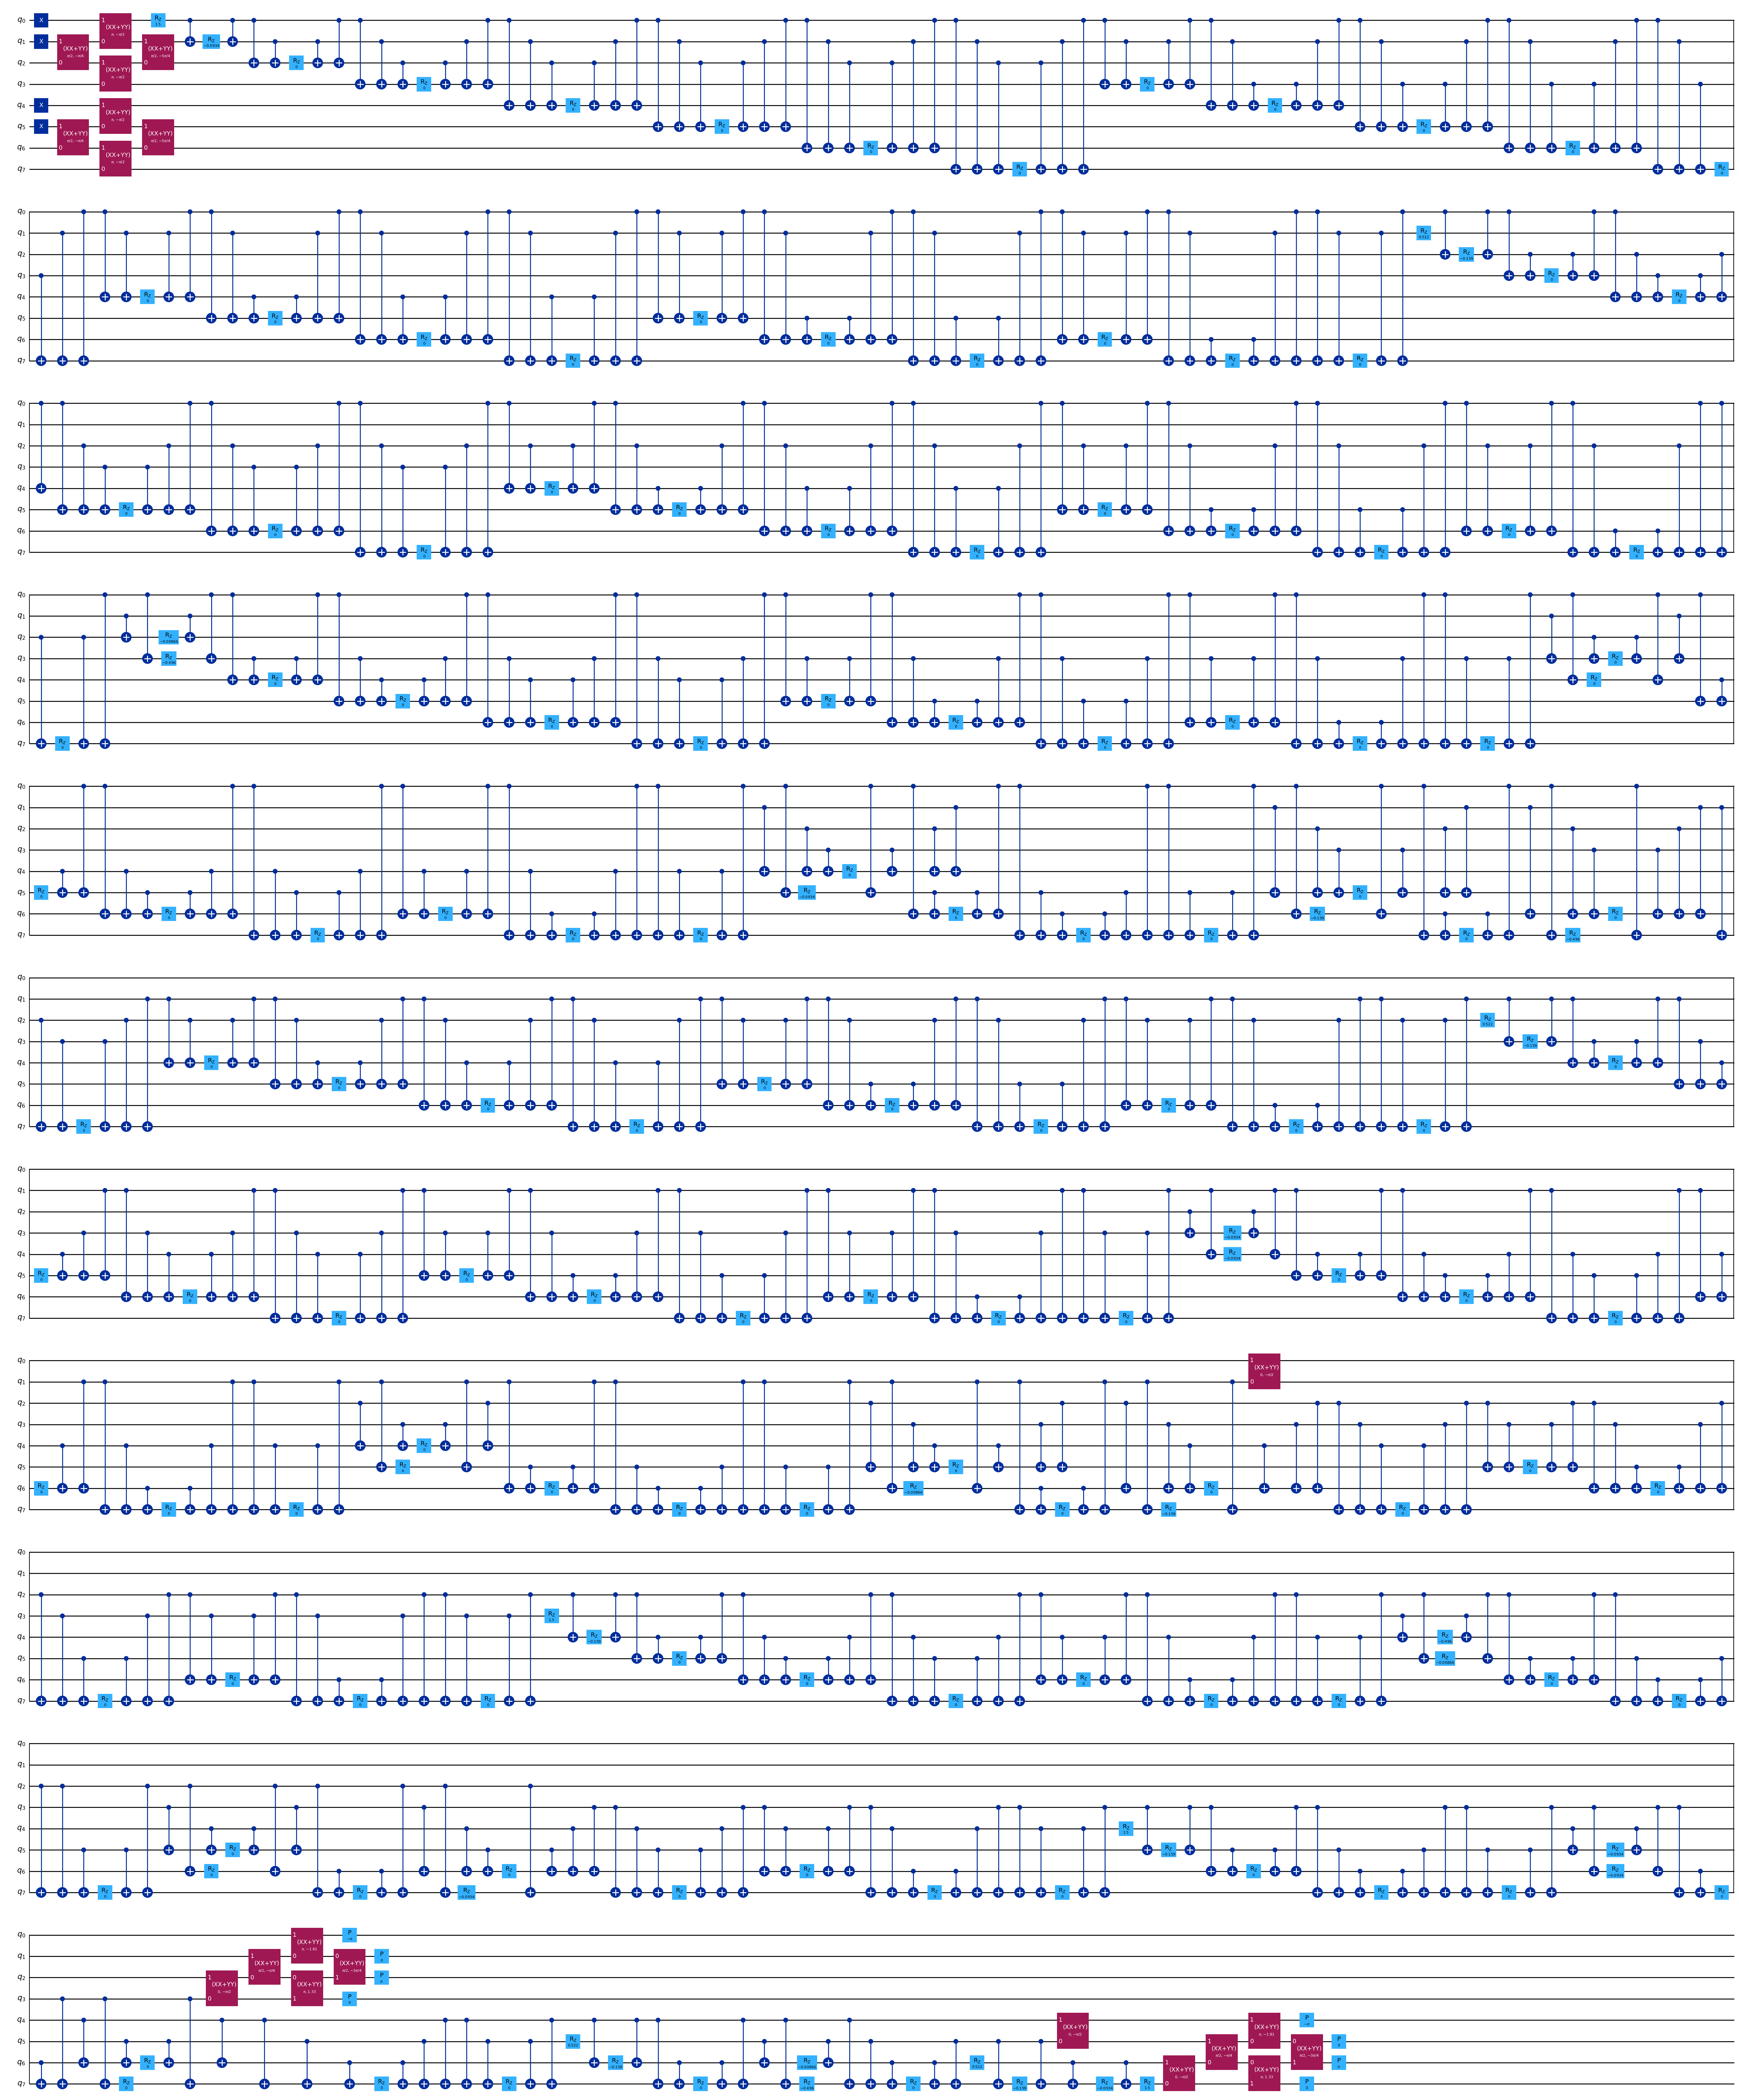

In [48]:
h4_igcr4_decomposed.draw("mpl", fold=80, idle_wires=False)


## 3. N2/cc-pVDZ: large-scale resource comparison

The final example mirrors the large comparison from the original notebook: ffsim spin-balanced UCJ against spin-balanced xquces iGCR-2 for the frozen-core N2 active space.


In [49]:
n2_R = 1.10
n2_basis = "cc-pvdz"
optimization_level = 3
transpile_seed = 12345

n2_mol = xq_utils.build_diatom("N", "N", n2_R, n2_basis)
n2_mf = xq_utils.run_rhf(n2_mol)
n2_active_space = xq_utils.active_space_from_frozen_core(n2_mf, 2)
n2_frozen = xq_utils.frozen_orbitals_from_active_space(n2_mf, n2_active_space)
n2_ccsd = xq_utils.run_rccsd(n2_mf, frozen=n2_frozen)

n2_norb = len(n2_active_space)
n2_nelec = xq_utils.active_nelec_from_mo_occ(n2_mf, n2_active_space)
n2_nocc = n2_nelec[0]

n2_ucj = ffsim.UCJOpSpinBalanced.from_t_amplitudes(np.asarray(n2_ccsd.t2, dtype=np.float64), t1=np.asarray(n2_ccsd.t1, dtype=np.complex128), n_reps=1)
n2_ffsim_circuit = QuantumCircuit(2 * n2_norb)
n2_ffsim_circuit.append(PrepareHartreeFockJW(n2_norb, n2_nelec), n2_ffsim_circuit.qubits)
n2_ffsim_circuit.append(UCJOpSpinBalancedJW(n2_ucj), n2_ffsim_circuit.qubits)

n2_ucj_balanced = UCJBalancedDFSeed(t2=n2_ccsd.t2, t1=n2_ccsd.t1, n_reps=1).build_ansatz()
n2_igcr2 = IGCR2SpinBalancedParameterization(norb=n2_norb, nocc=n2_nocc)
n2_igcr2_ansatz = n2_igcr2.ansatz_from_parameters(n2_igcr2.parameters_from_ucj_ansatz(n2_ucj_balanced))
n2_igcr2_circuit = igcr2_stateprep_jw_circuit(n2_igcr2_ansatz)


N2/cc-pvdz state-preparation stats (R = 1.1 A, norb = 26, nelec = (5, 5))
ffsim UCJ
---------
qubits:          52
depth:           834
gates:           22450
two-qubit gates: 4060
ops:             cx: 4060, rz: 9907, sx: 8405, x: 78

xquces iGCR-2
-------------
qubits:          52
depth:           508
gates:           10513
two-qubit gates: 1940
ops:             cx: 1940, rz: 4531, sx: 4022, x: 20


,ansatz,parameters,depth,gates,two_qubit_gates
0,ffsim UCJ,2054,834,22450,4060
1,xquces iGCR-2,1562,508,10513,1940


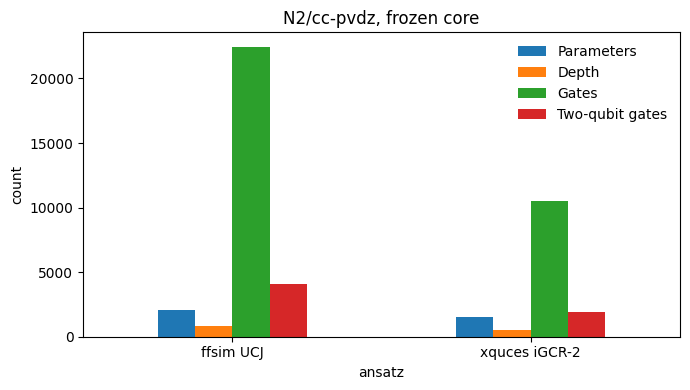

In [50]:
n2_parameters = {
    "ffsim UCJ": n2_ucj.n_params(norb=n2_norb, n_reps=1, with_final_orbital_rotation=True),
    "xquces iGCR-2": n2_igcr2.n_params,
}

n2_stats_raw = pretty_print_circuit_stats(
    [
        CircuitStatsJob(
            "ffsim UCJ",
            n2_ffsim_circuit,
        ),
        CircuitStatsJob("xquces iGCR-2", n2_igcr2_circuit),
    ],
    title=(
        f"N2/{n2_basis} state-preparation stats "
        f"(R = {n2_R} A, norb = {n2_norb}, nelec = {n2_nelec})"
    ),
    optimization_level=optimization_level,
    seed=transpile_seed,
)

n2_stats = pd.DataFrame(
    [
        {
            "ansatz": item.label,
            "parameters": n2_parameters[item.label],
            "depth": item.depth,
            "gates": item.gate_count,
            "two_qubit_gates": item.two_qubit_gate_count,
        }
        for item in n2_stats_raw
    ]
)

ax = n2_stats.set_index("ansatz")[metrics].plot.bar(figsize=(7, 4), rot=0)
ax.set_ylabel("count")
ax.set_title(f"N2/{n2_basis}, frozen core")
ax.legend(metric_labels, frameon=False)
plt.tight_layout()

n2_stats
